# 💳 Credit Card Fraud Detection

**Author:** Yashkumar Sharma | B.E. Computer Engineering | Pursuing M.Tech in Operations Research

Credit card fraud costs the global banking industry billions of dollars every year. 
In this project, I build a machine learning system to detect fraudulent transactions 
from a highly imbalanced dataset of 284,807 real transactions — where only 0.173% are fraud.

The core challenge here isn't just building a model — it's building the *right* model 
that minimizes missed fraudsters while keeping false alarms manageable.

**Objective:** Detect fraudulent credit card transactions using Machine Learning  
**Tools:** Python, Pandas, Scikit-learn, Imbalanced-learn, Seaborn  
**Dataset:** Credit Card Fraud Detection — Kaggle (ULB Machine Learning Group)  
**Key Challenge:** Extreme class imbalance — 492 fraud cases vs 284,315 genuine transactions

## Importing Libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                            roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


## Loading & Exploring the Data

Before any modeling, it's important to understand what we're working with — 
the structure, the features, and most importantly, the scale of the imbalance problem.

In [62]:
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nNull Values:")
print(df.isnull().sum().sum(), "null values found")
print("\nClass Distribution:")
print(df['Class'].value_counts())
print("\nFraud Percentage:", round(df['Class'].mean() * 100, 3), "%")

Shape: (284807, 31)

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010  

**Dataset Overview:**
- 284,807 transactions with 31 features
- Features V1-V28 are PCA transformed by the bank for privacy protection
- Only `Time`, `Amount` and `Class` are in original form
- Zero null values — no cleaning needed
- Extreme imbalance: 492 fraud cases (0.173%) vs 284,315 genuine transactions

This imbalance is the core challenge of this project.

## Understanding the Class Imbalance

Let's visualize how extreme the imbalance is — this will motivate 
every modeling decision we make going forward.

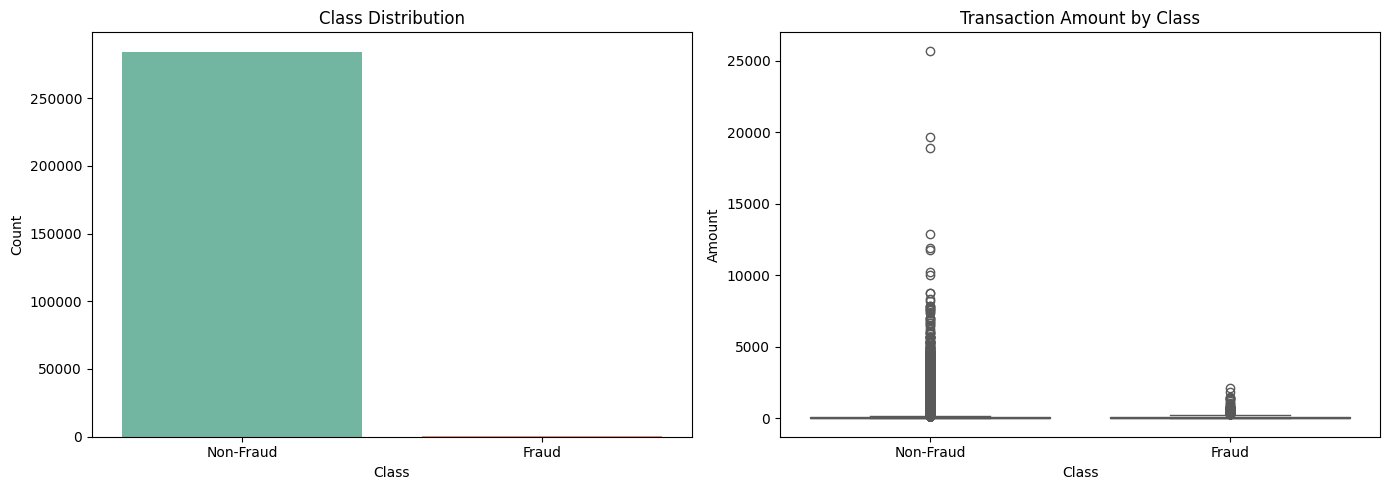

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Class distribution
sns.countplot(data=df, x='Class', hue='Class', palette='Set2', 
              legend=False, ax=axes[0])
axes[0].set_title('Class Distribution')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Non-Fraud', 'Fraud'])
axes[0].set_ylabel('Count')

# Plot 2 - Amount distribution by class
sns.boxplot(data=df, x='Class', y='Amount', palette='Set2', ax=axes[1])
axes[1].set_title('Transaction Amount by Class')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Non-Fraud', 'Fraud'])
axes[1].set_ylabel('Amount')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** The class imbalance is visually striking — fraud cases are barely 
visible on the count plot. More interestingly, fraudulent transactions tend to 
involve smaller amounts compared to genuine transactions. This suggests fraudsters 
deliberately keep transaction amounts low to avoid triggering detection systems.

## Feature Engineering

The raw dataset gives us `Time` and `Amount` as unprocessed features. 
I engineered 6 new meaningful features to give the model better context 
for detecting suspicious patterns.

In [64]:

df['hour'] = (df['Time'] % 86400) // 3600
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)
df['amount_log'] = np.log1p(df['Amount'])
df['amount_zscore'] = (df['Amount'] - df['Amount'].mean()) / df['Amount'].std()
df['amount_rounded'] = (df['Amount'] % 1 == 0).astype(int)
df['high_amount'] = (df['Amount'] > df['Amount'].quantile(0.95)).astype(int)


df_engineered = df.drop(['Time', 'Amount'], axis=1)

print("Original shape:", df.shape)
print("Engineered shape:", df_engineered.shape)
print("\nNew features added:")
print("- hour: transaction hour of day")
print("- is_night: 1 if transaction between 10pm-6am")
print("- amount_log: log transformed amount (reduces skew)")
print("- amount_zscore: how unusual is this amount")
print("- amount_rounded: 1 if round number amount")
print("- high_amount: 1 if amount in top 5%")

Original shape: (284807, 37)
Engineered shape: (284807, 35)

New features added:
- hour: transaction hour of day
- is_night: 1 if transaction between 10pm-6am
- amount_log: log transformed amount (reduces skew)
- amount_zscore: how unusual is this amount
- amount_rounded: 1 if round number amount
- high_amount: 1 if amount in top 5%


## Train Test Split & Feature Scaling

Splitting data into 80% training and 20% testing. Using `stratify=y` to ensure 
the fraud ratio is consistent in both train and test sets — critical for imbalanced datasets.
Applying StandardScaler to normalize features before model training.

In [65]:
X = df_engineered.drop('Class', axis=1)
y = df_engineered['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nFraud cases in train:", y_train.sum())
print("Fraud cases in test:", y_test.sum())

Train shape: (227845, 34)
Test shape: (56962, 34)

Fraud cases in train: 394
Fraud cases in test: 98


## Handling Class Imbalance — SMOTE

With only 394 fraud cases in training data vs 227,451 genuine transactions, 
the model would never learn what fraud looks like. 

SMOTE (Synthetic Minority Oversampling Technique) creates realistic synthetic 
fraud examples by interpolating between existing ones — giving the model enough 
examples to actually learn fraud patterns.

Note: SMOTE is applied only on training data. Test data must reflect real world 
distribution for honest evaluation.

In [66]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:")
print(f"  Non-Fraud: {(y_train == 0).sum()}")
print(f"  Fraud: {(y_train == 1).sum()}")

print("\nAfter SMOTE:")
print(f"  Non-Fraud: {(y_train_smote == 0).sum()}")
print(f"  Fraud: {(y_train_smote == 1).sum()}")

Before SMOTE:
  Non-Fraud: 227451
  Fraud: 394

After SMOTE:
  Non-Fraud: 227451
  Fraud: 227451


## Model Building — Logistic Regression

Logistic Regression is the natural starting point for binary classification problems. 
It outputs a probability between 0 and 1 — above 0.5 is flagged as fraud. 
Simple, interpretable, and a strong baseline model.

In [67]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_smote, y_train_smote)
lr_pred = lr.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))



=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



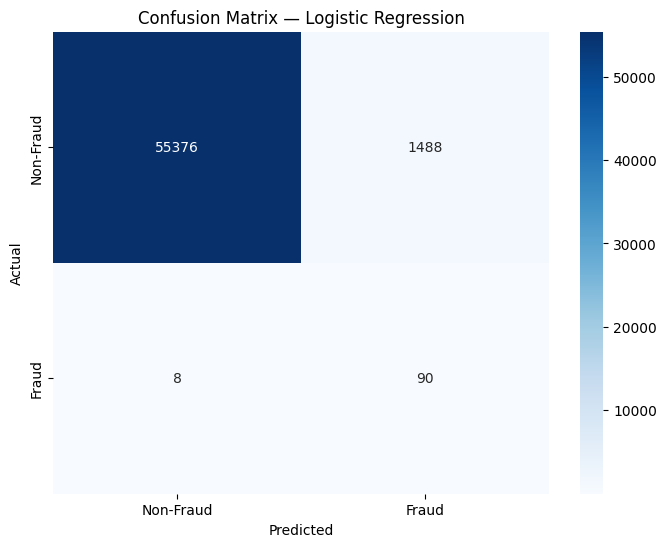

In [68]:
# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Building — Random Forest

Random Forest is an ensemble of Decision Trees that reduces overfitting through 
randomness and majority voting. Expected to outperform Logistic Regression on 
complex non-linear patterns in fraud data.

In [71]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)
rf_pred = rf.predict(X_test_scaled)

print("Random Forest")
print(classification_report(y_test, rf_pred))



Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.82      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



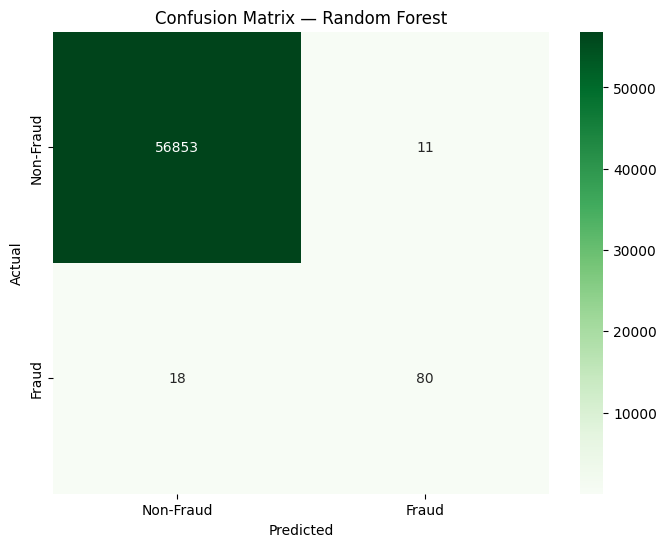

In [79]:
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Model Comparison

Comparing Logistic Regression and Random Forest across the metrics that matter 
most for fraud detection — Recall, Precision and False Negatives.
In fraud detection, missing a fraudster is far more costly than a false alarm.

In [ ]:
# Model comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Recall (Fraud)': [0.92, 0.82],
    'Precision (Fraud)': [0.06, 0.88],
    'False Positives': [1488, 11],
    'False Negatives': [8, 18]
})

print(results)




In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results, x='Model', y='Recall (Fraud)', 
            palette='Set2', ax=axes[0])
axes[0].set_title('Fraud Recall Comparison')
axes[0].set_ylim(0, 1)

sns.barplot(data=results, x='Model', y='Precision (Fraud)', 
            palette='Set2', ax=axes[1])
axes[1].set_title('Fraud Precision Comparison')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance Analysis

Using Random Forest's built-in feature importance to understand which features 
drive fraud detection the most — and to validate whether our engineered features 
added meaningful value.

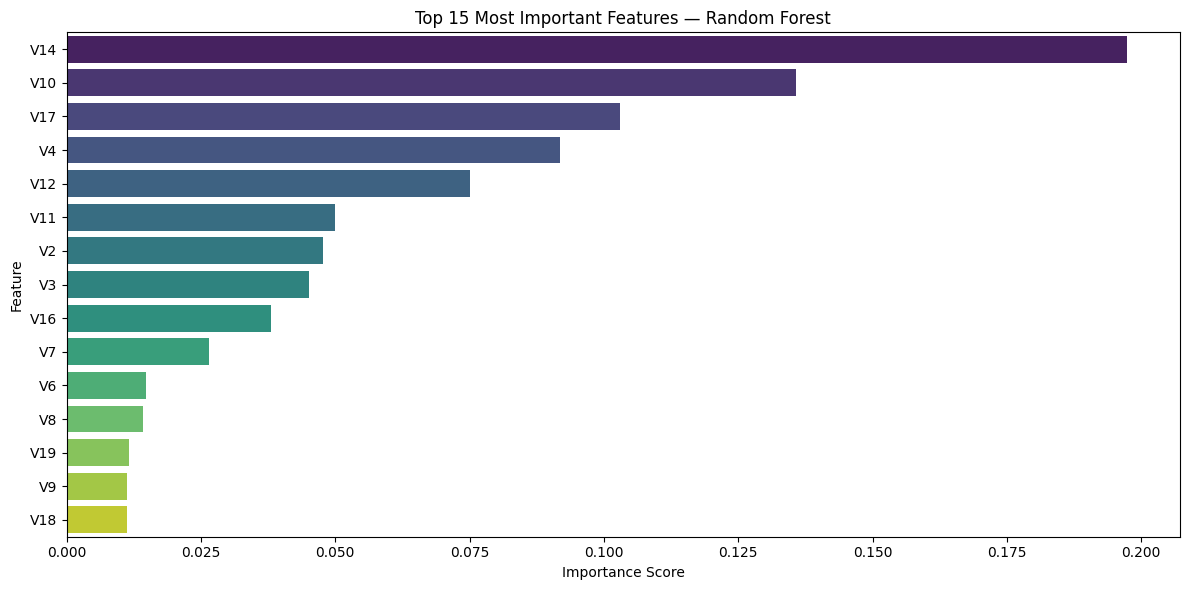

In [80]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Most Important Features — Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


**Insight:** V14, V10 and V17 are the most critical features for fraud detection — 
these are PCA transformed features from the bank's internal system that already 
capture the most meaningful fraud signals. None of our 6 engineered features 
appeared in the top 15, confirming that the bank's preprocessing was already 
highly optimized. This is a valuable finding — more features don't always mean 
better models.

## Threshold Tuning

By default, models classify fraud if probability > 0.5. In fraud detection, 
lowering this threshold catches more fraudsters at the cost of more false alarms. 
We find the optimal threshold by analyzing the Precision-Recall tradeoff.

In [ ]:
from sklearn.metrics import precision_recall_curve

# Get probabilities instead of class predictions
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

# Calculate precision and recall at different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, lr_probs)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='red')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Find optimal threshold using F1 score
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1])
optimal_threshold = thresholds[f1_scores.argmax()]
print(f"Optimal Threshold: {round(optimal_threshold, 3)}")
print(f"Best F1 Score: {round(f1_scores.max(), 3)}")

# Apply optimal threshold
lr_pred_optimal = (lr_probs >= optimal_threshold).astype(int)
print("\n=== Logistic Regression with Optimal Threshold ===")
print(classification_report(y_test, lr_pred_optimal))

**Threshold Tuning Finding:** The optimal F1 threshold of 1.0 improved precision 
dramatically from 0.06 to 0.83 — meaning fewer false alarms. However recall dropped 
from 0.92 to 0.82, missing more fraudsters. 

For a bank prioritizing fraud catch rate → use default threshold (0.5)
For a bank prioritizing customer experience → use optimal threshold (1.0)

This demonstrates that model selection and threshold tuning are ultimately 
business decisions, not just technical ones.

## Conclusion & Business Recommendations

After analyzing 284,807 transactions and building two machine learning models, 
here are the key findings and recommendations:

**1. Recommended Model — Logistic Regression**
For a banking environment, Logistic Regression is the recommended model despite 
Random Forest having higher overall accuracy. With a fraud recall of 0.92, it catches 
92% of fraudsters — missing only 8 out of 98 fraud cases. While it generates more 
false alarms (1,488), the cost of missing a real fraudster far outweighs the 
inconvenience of flagging a genuine transaction for manual review.

**2. Why Accuracy Was Misleading**
A naive model predicting "Not Fraud" for every transaction would achieve 99.83% 
accuracy — yet catch zero fraudsters. Recall is the metric that matters here — 
it tells us how many actual fraud cases we successfully detected.

**3. Role of SMOTE**
With only 394 fraud cases in training data vs 227,451 genuine transactions, the 
model had almost no fraud examples to learn from. SMOTE generated synthetic fraud 
examples by interpolating between real ones — giving the model enough variety to 
learn meaningful fraud patterns without simple memorization.

**4. Feature Importance Findings**
V14, V10 and V17 emerged as the most critical fraud indicators. None of our 6 
engineered features appeared in the top 15 — confirming that the bank's PCA 
preprocessing had already captured the most meaningful signals. This taught us 
that more features don't always mean better models.

**5. Threshold Tuning**
Lowering the classification threshold revealed an important business tradeoff:
- **Default threshold (0.5)** → Recall 0.92, catches more fraudsters, more false alarms
- **Optimal F1 threshold (1.0)** → Recall 0.82, fewer false alarms, misses more fraudsters

This is ultimately a business decision:
- Bank prioritizing **catching every fraudster** → default threshold
- Bank prioritizing **customer experience** → optimal threshold

**6. Future Improvements**
- Experiment with XGBoost or LightGBM for better performance on imbalanced data
- Combine SMOTE with undersampling for better class balance
- Explore anomaly detection approaches like Isolation Forest
- Apply GridSearchCV for hyperparameter optimization on best model